# Persistent Homology of Regional Time Series



This notebook reproduces the regional time-series topology analysis accompanying the paper Beyond Activation Maps: Higher-Order Information and Temporal Topology of Decodable Cognitive States in fMRI.

For each brain state class $c$, the analysis compares the significant region set $\mathcal{M}_c$ with the low-weight control set $\mathcal{L}_c$. Each regional time series $\vec{x}_i=(x_{i1},\dots,x_{i\nl})$ is mapped to a delay-coordinate point cloud, persistent homology is computed up to $H_1$, and the resulting diagrams are summarized by the number of finite $H_1$ features, total persistence $P(D_1)$, and maximal lifetime $M(D_1)$.

The notebook is the only layer that knows about files and folders. The Python module imported below contains only the in-memory TDA computations, aggregations, and figure construction.

## 1. Imports

The notebook uses the Python environment selected as the active Jupyter kernel. The required packages are `numpy`, `pandas`, `matplotlib`, `ripser`, `IPython`, and `jupyter`; install them with `pip install -r requirements.txt`.

In [13]:
from __future__ import annotations

import importlib.metadata as importlib_metadata
import json
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print("numpy", np.__version__)
print("pandas", pd.__version__)

numpy 1.26.4
pandas 2.2.3


## 2. Project Folder

The notebook is self-contained with respect to the folder that contains it. You can rename that folder and still run the notebook, as long as `region_persistence.py`, `requirements.txt`, and `examples/mini_data/` remain next to the notebook.

In [14]:
PROJECT_DIR = Path.cwd().resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from region_persistence import (  # noqa: E402
    EXPERIMENT_STATES,
    STATE_LABELS,
    SurrogateConfig,
    TakensConfig,
    aggregate_actual,
    aggregate_null,
    build_actual_rows,
    build_null_rows,
    build_subjectwise_comparison,
    make_actual_comparison_figures,
    make_null_comparison_figures,
    records_from_frame,
    validate_experiments,
    validate_phase_encoding,
    validate_surrogate_config,
    validate_takens_config,
)


def make_output_tag(
    experiments: list[str],
    takens: TakensConfig,
    surrogate: SurrogateConfig,
    phase_encoding: str,
    max_subjects: int | None,
) -> str:
    experiments = validate_experiments(experiments)
    validate_takens_config(takens)
    validate_surrogate_config(surrogate)
    phase_encoding = validate_phase_encoding(phase_encoding)
    experiment_slug = "".join(experiment[0].lower() for experiment in experiments)
    subject_slug = "full" if max_subjects is None else f"n{max_subjects}"
    null_slug = {"shuffle": "shuf", "cyclic_shift": "cyclic"}[surrogate.null_model]
    return (
        f"{subject_slug}_{experiment_slug}_{phase_encoding.lower()}"
        f"_m{takens.dim}_tau{takens.delay}_stride{takens.stride}"
        f"_h{takens.maxdim}_{surrogate.n_surrogates}{null_slug}_seed{surrogate.seed}"
    )


print("Project folder:", PROJECT_DIR)

Project folder: /Users/dopeyhex/Documents/Учёба/Лаборатории/МЛАТИП/brain/code_nips


## 3. Parameters

The default configuration runs on the time series bundled with this folder in `examples/mini_data/`. To run the full released data instead, put `data_Regions_with_low_weights/` and `data_Significant_regions/` next to the notebook and set `DATA_ROOT = PROJECT_DIR`.

In [15]:
EXPERIMENTS = validate_experiments(["LANGUAGE"])
PHASE_ENCODING = validate_phase_encoding("RL")

DATA_ROOT = PROJECT_DIR / "examples" / "mini_data"
LOW_REGIONS_DIR = DATA_ROOT / "data_Regions_with_low_weights"
SIGNIFICANT_REGIONS_DIR = DATA_ROOT / "data_Significant_regions"
OUTPUT_ROOT = PROJECT_DIR / "takens_batch_compare_outputs"

TAKENS = TakensConfig(dim=3, delay=2, stride=1, maxdim=1)
SURROGATE = SurrogateConfig(null_model="shuffle", n_surrogates=5, seed=42)

MAX_SUBJECTS = None
ALLOW_MISSING_SUBJECTS = False
USE_CACHE = True
OUTPUT_TAG = make_output_tag(EXPERIMENTS, TAKENS, SURROGATE, PHASE_ENCODING, MAX_SUBJECTS)
OUTPUT_DIR = OUTPUT_ROOT / OUTPUT_TAG
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REGION_ROOTS = {
    "low": LOW_REGIONS_DIR,
    "top": SIGNIFICANT_REGIONS_DIR,
}
FRAME_CACHE: dict[tuple[str, str, str, str], pd.DataFrame] = {}

#print("Data root:", DATA_ROOT)
#print("Low-weight regions:", LOW_REGIONS_DIR)
#print("Significant regions:", SIGNIFICANT_REGIONS_DIR)
#print("Output directory:", OUTPUT_DIR)

## 4. Notebook I/O Helpers and Data Check

The constants above are the only run-defining parameters. The helper functions below are notebook-local because they deal with files, folders, cache, and metadata rather than with the TDA computation itself.

In [16]:
def subjects_with_complete_state_files(
    region_root: Path,
    experiment: str,
    phase_encoding: str,
) -> list[str]:
    experiment_dir = region_root / experiment
    observed_subjects = {
        path.name.split("_")[0]
        for path in experiment_dir.glob(f"*_{phase_encoding}_*.csv")
    }
    complete_subjects = []
    for subject_id in observed_subjects:
        has_all_states = all(
            (experiment_dir / f"{subject_id}_{phase_encoding}_{state}.csv").exists()
            for state in EXPERIMENT_STATES[experiment]
        )
        if has_all_states:
            complete_subjects.append(subject_id)
    return sorted(complete_subjects)


def subject_inventory(
    experiment: str,
    low_regions_dir: Path,
    significant_regions_dir: Path,
    phase_encoding: str,
) -> dict:
    low_subjects = set(subjects_with_complete_state_files(low_regions_dir, experiment, phase_encoding))
    top_subjects = set(subjects_with_complete_state_files(significant_regions_dir, experiment, phase_encoding))
    shared_subjects = low_subjects & top_subjects
    return {
        "experiment": experiment,
        "low_subjects": sorted(low_subjects),
        "significant_subjects": sorted(top_subjects),
        "shared_subjects": sorted(shared_subjects),
        "low_only_subjects": sorted(low_subjects - shared_subjects),
        "significant_only_subjects": sorted(top_subjects - shared_subjects),
    }


def load_region_frame(
    region_root: Path,
    experiment: str,
    subject_id: str,
    phase_encoding: str,
    state: str,
) -> pd.DataFrame:
    path = region_root / experiment / f"{subject_id}_{phase_encoding}_{state}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def preview_subjects(subjects: list[str], limit: int = 5) -> str:
    if len(subjects) <= limit:
        return ", ".join(subjects)
    return ", ".join(subjects[:limit]) + f", ... ({len(subjects)} total)"


def collect_input_summary(
    experiments: list[str],
    low_regions_dir: Path,
    significant_regions_dir: Path,
    phase_encoding: str,
) -> list[dict]:
    rows = []
    for experiment in experiments:
        inventory = subject_inventory(
            experiment,
            low_regions_dir,
            significant_regions_dir,
            phase_encoding,
        )
        rows.append(
            {
                "experiment": experiment,
                "phase_encoding": phase_encoding,
                "n_low_subjects": len(inventory["low_subjects"]),
                "n_significant_subjects": len(inventory["significant_subjects"]),
                "n_shared_subjects": len(inventory["shared_subjects"]),
                "n_low_only_subjects": len(inventory["low_only_subjects"]),
                "n_significant_only_subjects": len(inventory["significant_only_subjects"]),
                "n_low_files": len(list((low_regions_dir / experiment).glob(f"*_{phase_encoding}_*.csv"))),
                "n_significant_files": len(list((significant_regions_dir / experiment).glob(f"*_{phase_encoding}_*.csv"))),
            }
        )
    return rows


def package_versions() -> dict[str, str]:
    versions = {}
    for package_name in ["numpy", "pandas", "matplotlib", "ripser"]:
        try:
            versions[package_name] = importlib_metadata.version(package_name)
        except importlib_metadata.PackageNotFoundError:
            versions[package_name] = "not-installed"
    return versions


def build_notebook_metadata(
    actual_df: pd.DataFrame | None = None,
    null_df: pd.DataFrame | None = None,
    elapsed_seconds: float | None = None,
) -> dict:
    metadata = {
        "paper": {
            "title": (
                "Beyond Activation Maps: Higher-Order Information and Temporal "
                "Topology of Decodable Cognitive States in fMRI"
            ),
            "manuscript": "paper_nips/neurips_2026.tex",
        },
        "parameters": {
            "experiments": EXPERIMENTS,
            "phase_encoding": PHASE_ENCODING,
            "takens_dim": TAKENS.dim,
            "takens_delay": TAKENS.delay,
            "takens_stride": TAKENS.stride,
            "maxdim": TAKENS.maxdim,
            "null_model": SURROGATE.null_model,
            "n_surrogates": SURROGATE.n_surrogates,
            "seed": SURROGATE.seed,
            "max_subjects": MAX_SUBJECTS,
            "tag": OUTPUT_TAG,
        },
        "paths": {
            "project_dir": str(PROJECT_DIR),
            "data_root": str(DATA_ROOT),
            "low_regions": str(LOW_REGIONS_DIR),
            "significant_regions": str(SIGNIFICANT_REGIONS_DIR),
            "output_root": str(OUTPUT_ROOT),
            "output_dir": str(OUTPUT_DIR),
        },
        "input_summary": collect_input_summary(
            EXPERIMENTS,
            LOW_REGIONS_DIR,
            SIGNIFICANT_REGIONS_DIR,
            PHASE_ENCODING,
        ),
        "software": {
            "python": platform.python_version(),
            "executable": sys.executable,
            "packages": package_versions(),
        },
        "command": "notebook",
        "use_cache": USE_CACHE,
        "empirical_p_resolution": 1.0 / (SURROGATE.n_surrogates + 1),
    }
    if elapsed_seconds is not None:
        metadata["elapsed_seconds"] = round(float(elapsed_seconds), 2)
    if actual_df is not None:
        metadata["actual_rows"] = int(len(actual_df))
    if null_df is not None:
        metadata["null_rows"] = int(len(null_df))
    return metadata


def cache_matches_current_run() -> bool:
    metadata_path = OUTPUT_DIR / "run_metadata.json"
    if not metadata_path.exists():
        return False
    metadata = json.loads(metadata_path.read_text())
    expected = build_notebook_metadata()
    stable_keys = ["parameters", "paths", "input_summary"]
    return all(metadata.get(key) == expected.get(key) for key in stable_keys)


def save_figures(figures: dict[str, object], output_dir: Path) -> list[Path]:
    output_dir.mkdir(parents=True, exist_ok=True)
    saved_paths = []
    for filename, figure in figures.items():
        path = output_dir / filename
        figure.savefig(path, dpi=200, bbox_inches="tight")
        plt.close(figure)
        saved_paths.append(path)
    return saved_paths


def write_metadata(metadata: dict, output_dir: Path) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "run_metadata.json").write_text(
        json.dumps(metadata, indent=2, sort_keys=True) + "\n"
    )
    pd.json_normalize(metadata).to_csv(output_dir / "notebook_run_metadata.csv", index=False)


CACHE_IS_VALID = USE_CACHE and cache_matches_current_run()
print("Cache valid for current parameters:", CACHE_IS_VALID)

subject_counts = []
for experiment in EXPERIMENTS:
    inventory = subject_inventory(
        experiment,
        LOW_REGIONS_DIR,
        SIGNIFICANT_REGIONS_DIR,
        PHASE_ENCODING,
    )
    if (
        inventory["low_only_subjects"] or inventory["significant_only_subjects"]
    ) and not ALLOW_MISSING_SUBJECTS:
        raise ValueError(
            f"{experiment} has unmatched subjects. "
            f"Only in low-weight folder: {preview_subjects(inventory['low_only_subjects'])}. "
            f"Only in significant-region folder: {preview_subjects(inventory['significant_only_subjects'])}."
        )
    subject_counts.append(
        {
            "experiment": experiment,
            "states": ", ".join(STATE_LABELS[state] for state in EXPERIMENT_STATES[experiment]),
            "n_low_subjects": len(inventory["low_subjects"]),
            "n_significant_subjects": len(inventory["significant_subjects"]),
            "n_shared_subjects": len(inventory["shared_subjects"]),
            "n_low_only_subjects": len(inventory["low_only_subjects"]),
            "n_significant_only_subjects": len(inventory["significant_only_subjects"]),
        }
    )

subject_counts_df = pd.DataFrame(subject_counts)
display(subject_counts_df)

Cache valid for current parameters: True


,experiment,states,n_low_subjects,n_significant_subjects,n_shared_subjects,n_low_only_subjects,n_significant_only_subjects
0,LANGUAGE,"Math, Story",1,1,1,0,0


## 5. Original Time Series

One row corresponds to one regional time series $\vec{x}_i$ for one subject, state, and source. In the saved tables, `source = top` denotes $\mathcal{M}_c$, and `source = low` denotes $\mathcal{L}_c$. The main quantity is `H1_total_persistence`, i.e. $P(D_1)$ for the Takens point cloud.

In [17]:
def iter_region_records():
    started = time.time()
    for experiment in EXPERIMENTS:
        inventory = subject_inventory(
            experiment,
            LOW_REGIONS_DIR,
            SIGNIFICANT_REGIONS_DIR,
            PHASE_ENCODING,
        )
        subjects = inventory["shared_subjects"]
        if MAX_SUBJECTS is not None:
            subjects = subjects[:MAX_SUBJECTS]
        total_subjects = len(subjects)

        for subject_index, subject_id in enumerate(subjects, start=1):
            if subject_index == 1 or subject_index % 50 == 0 or subject_index == total_subjects:
                elapsed = time.time() - started
                print(
                    f"[load][{experiment}] loaded {subject_index}/{total_subjects} "
                    f"subjects after {elapsed:.1f}s",
                    flush=True,
                )

            for source, region_root in REGION_ROOTS.items():
                for state in EXPERIMENT_STATES[experiment]:
                    frame = load_region_frame(
                        region_root,
                        experiment,
                        subject_id,
                        PHASE_ENCODING,
                        state,
                    )
                    yield from records_from_frame(
                        frame=frame,
                        experiment=experiment,
                        source=source,
                        state=state,
                        subject_id=subject_id,
                    )


def compute_or_load_actual_rows() -> pd.DataFrame:
    actual_path = OUTPUT_DIR / "actual_rows.csv"
    if USE_CACHE and CACHE_IS_VALID and actual_path.exists():
        print(f"Loading cached actual rows from {actual_path}")
        return pd.read_csv(actual_path)
    actual_df = build_actual_rows(iter_region_records(), TAKENS, progress_every=500)
    actual_df.to_csv(actual_path, index=False)
    #print(f"Saved actual rows to {actual_path}")
    return actual_df


actual_rows = compute_or_load_actual_rows()
display(actual_rows.head())
print("actual_rows shape:", actual_rows.shape)

Loading cached actual rows from /Users/dopeyhex/Documents/Учёба/Лаборатории/МЛАТИП/brain/code_nips/takens_batch_compare_outputs/full_l_rl_m3_tau2_stride1_h1_5shuf_seed42/actual_rows.csv


,experiment,source,state,subject_id,region_id,n_timepoints,n_embedded_points,H0_features,H0_total_persistence,H0_max_lifetime,H0_entropy,H1_features,H1_total_persistence,H1_max_lifetime,H1_entropy
0,LANGUAGE,low,math,100206,1,10,6,5,5.296179,1.132416,1.607464,0,0.0,0.0,0.0
1,LANGUAGE,low,math,100206,2,10,6,5,5.277230,1.160516,1.606608,0,0.0,0.0,0.0
2,LANGUAGE,low,story,100206,1,10,6,5,5.071541,1.078658,1.608103,0,0.0,0.0,0.0
3,LANGUAGE,low,story,100206,2,10,6,5,4.902348,1.026617,1.608708,0,0.0,0.0,0.0
4,LANGUAGE,top,math,100206,11,10,6,5,4.659301,0.981198,1.608986,0,0.0,0.0,0.0


actual_rows shape: (8, 15)


## 6. Aggregates for Original Signals

`actual_aggregate.csv` summarizes the $H_1$ diagram statistics for each task, state, and region set. The subject-wise table checks whether $P(D_1)$ is larger for $\mathcal{L}_c$ than for $\mathcal{M}_c$ after averaging within each subject.

In [18]:
actual_aggregate = aggregate_actual(actual_rows)
actual_aggregate_path = OUTPUT_DIR / "actual_aggregate.csv"
actual_aggregate.to_csv(actual_aggregate_path, index=False)
display(actual_aggregate)
#print("Saved:", actual_aggregate_path)

subjectwise_actual_comparison = build_subjectwise_comparison(actual_rows)
subjectwise_path = OUTPUT_DIR / "subjectwise_actual_comparison.csv"
subjectwise_actual_comparison.to_csv(subjectwise_path, index=False)
display(subjectwise_actual_comparison)
#print("Saved:", subjectwise_path)

,experiment,state,source,n_rows,n_subjects,H1_features_mean,H1_features_std,H1_total_persistence_mean,H1_total_persistence_std,H1_max_lifetime_mean,H1_max_lifetime_std
0,LANGUAGE,math,low,2,1,0.0,0.0,0.0,0.0,0.0,0.0
1,LANGUAGE,math,top,2,1,0.0,0.0,0.0,0.0,0.0,0.0
2,LANGUAGE,story,low,2,1,0.0,0.0,0.0,0.0,0.0,0.0
3,LANGUAGE,story,top,2,1,0.0,0.0,0.0,0.0,0.0,0.0


,experiment,state,n_subjects,H1_features_mean_low_minus_top,H1_features_rate_low_gt_top,H1_total_persistence_mean_low_minus_top,H1_total_persistence_rate_low_gt_top,H1_max_lifetime_mean_low_minus_top,H1_max_lifetime_rate_low_gt_top
0,LANGUAGE,math,1,0.0,0.0,0.0,0.0,0.0,0.0
1,LANGUAGE,story,1,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Surrogate Time Series

The surrogate table compares each original regional time series with surrogate versions of the same signal.

- `shuffle` randomly permutes all time points and removes the temporal order.
- `cyclic_shift` circularly shifts the time series. It preserves the local temporal structure but changes the temporal origin.

In [19]:
def get_region_series(
    experiment: str,
    source: str,
    state: str,
    subject_id: str,
    region_id: int,
) -> np.ndarray:
    frame_key = (experiment, source, state, str(subject_id))
    if frame_key not in FRAME_CACHE:
        FRAME_CACHE[frame_key] = load_region_frame(
            REGION_ROOTS[source],
            experiment,
            str(subject_id),
            PHASE_ENCODING,
            state,
        )
    frame = FRAME_CACHE[frame_key]
    region_column = frame.columns[0]
    time_columns = [column for column in frame.columns if column != region_column]
    matching = frame.loc[frame[region_column].astype(int) == int(region_id), time_columns]
    if matching.empty:
        raise KeyError((experiment, source, state, subject_id, region_id))
    return matching.iloc[0].to_numpy(dtype=float)


def compute_or_load_null_rows(actual_df: pd.DataFrame) -> pd.DataFrame:
    null_path = OUTPUT_DIR / "null_rows.csv"
    if USE_CACHE and CACHE_IS_VALID and null_path.exists():
        print(f"Loading cached null rows from {null_path}")
        return pd.read_csv(null_path)
    null_df = build_null_rows(
        actual_df=actual_df,
        series_getter=get_region_series,
        takens=TAKENS,
        surrogate=SURROGATE,
        progress_every=500,
    )
    null_df.to_csv(null_path, index=False)
    #print(f"Saved null rows to {null_path}")
    return null_df


null_rows = compute_or_load_null_rows(actual_rows)
display(null_rows.head())
print("null_rows shape:", null_rows.shape)

Loading cached null rows from /Users/dopeyhex/Documents/Учёба/Лаборатории/МЛАТИП/brain/code_nips/takens_batch_compare_outputs/full_l_rl_m3_tau2_stride1_h1_5shuf_seed42/null_rows.csv


,experiment,source,state,subject_id,region_id,actual_H1_total_persistence,null_H1_total_persistence_mean,null_H1_total_persistence_std,actual_H1_features,null_H1_features_mean,actual_H1_max_lifetime,null_H1_max_lifetime_mean,delta_H1_total_persistence,delta_H1_features,delta_H1_max_lifetime,empirical_p_H1_total_persistence,empirical_p_H1_max_lifetime,null_model
0,LANGUAGE,low,math,100206,1,0.0,0.174393,0.233169,0,0.8,0.0,0.166758,-0.174393,-0.8,-0.166758,1.0,1.0,shuffle
1,LANGUAGE,low,math,100206,2,0.0,0.217452,0.202909,0,0.6,0.0,0.217452,-0.217452,-0.6,-0.217452,1.0,1.0,shuffle
2,LANGUAGE,low,story,100206,1,0.0,0.125542,0.123724,0,1.0,0.0,0.090281,-0.125542,-1.0,-0.090281,1.0,1.0,shuffle
3,LANGUAGE,low,story,100206,2,0.0,0.071643,0.088056,0,0.6,0.0,0.061594,-0.071643,-0.6,-0.061594,1.0,1.0,shuffle
4,LANGUAGE,top,math,100206,11,0.0,0.002057,0.004114,0,0.2,0.0,0.002057,-0.002057,-0.2,-0.002057,1.0,1.0,shuffle


null_rows shape: (8, 18)


## 8. Aggregates for Surrogates

`delta_H1_total_persistence` is defined as $P(D_1)$ for the original signal minus the surrogate mean. Values near zero indicate that the selected surrogate construction preserves the observed $H_1$ total persistence.

In [20]:
null_aggregate = aggregate_null(null_rows)
null_aggregate_path = OUTPUT_DIR / "null_aggregate.csv"
null_aggregate.to_csv(null_aggregate_path, index=False)
display(null_aggregate)
#print("Saved:", null_aggregate_path)

,experiment,state,source,null_model,n_rows,n_subjects,delta_H1_total_persistence_mean,delta_H1_total_persistence_std,delta_H1_max_lifetime_mean,delta_H1_max_lifetime_std,p_lt_005_rate,p_lt_010_rate
0,LANGUAGE,math,low,shuffle,2,1,-0.195923,0.030447,-0.192105,0.035846,0.0,0.0
1,LANGUAGE,math,top,shuffle,2,1,-0.091951,0.127129,-0.091951,0.127129,0.0,0.0
2,LANGUAGE,story,low,shuffle,2,1,-0.098592,0.038112,-0.075938,0.020285,0.0,0.0
3,LANGUAGE,story,top,shuffle,2,1,-0.071236,0.001986,-0.071236,0.001986,0.0,0.0


## 9. Generate Figures

The plotting functions save the comparison figures used in the manuscript workflow.

In [21]:
actual_figures = make_actual_comparison_figures(actual_rows)
null_figures = make_null_comparison_figures(null_rows)
actual_figure_paths = save_figures(actual_figures, OUTPUT_DIR)
null_figure_paths = save_figures(null_figures, OUTPUT_DIR)

#for path in actual_figure_paths + null_figure_paths:
#    print("Saved:", path)

language_actual_comparison.png


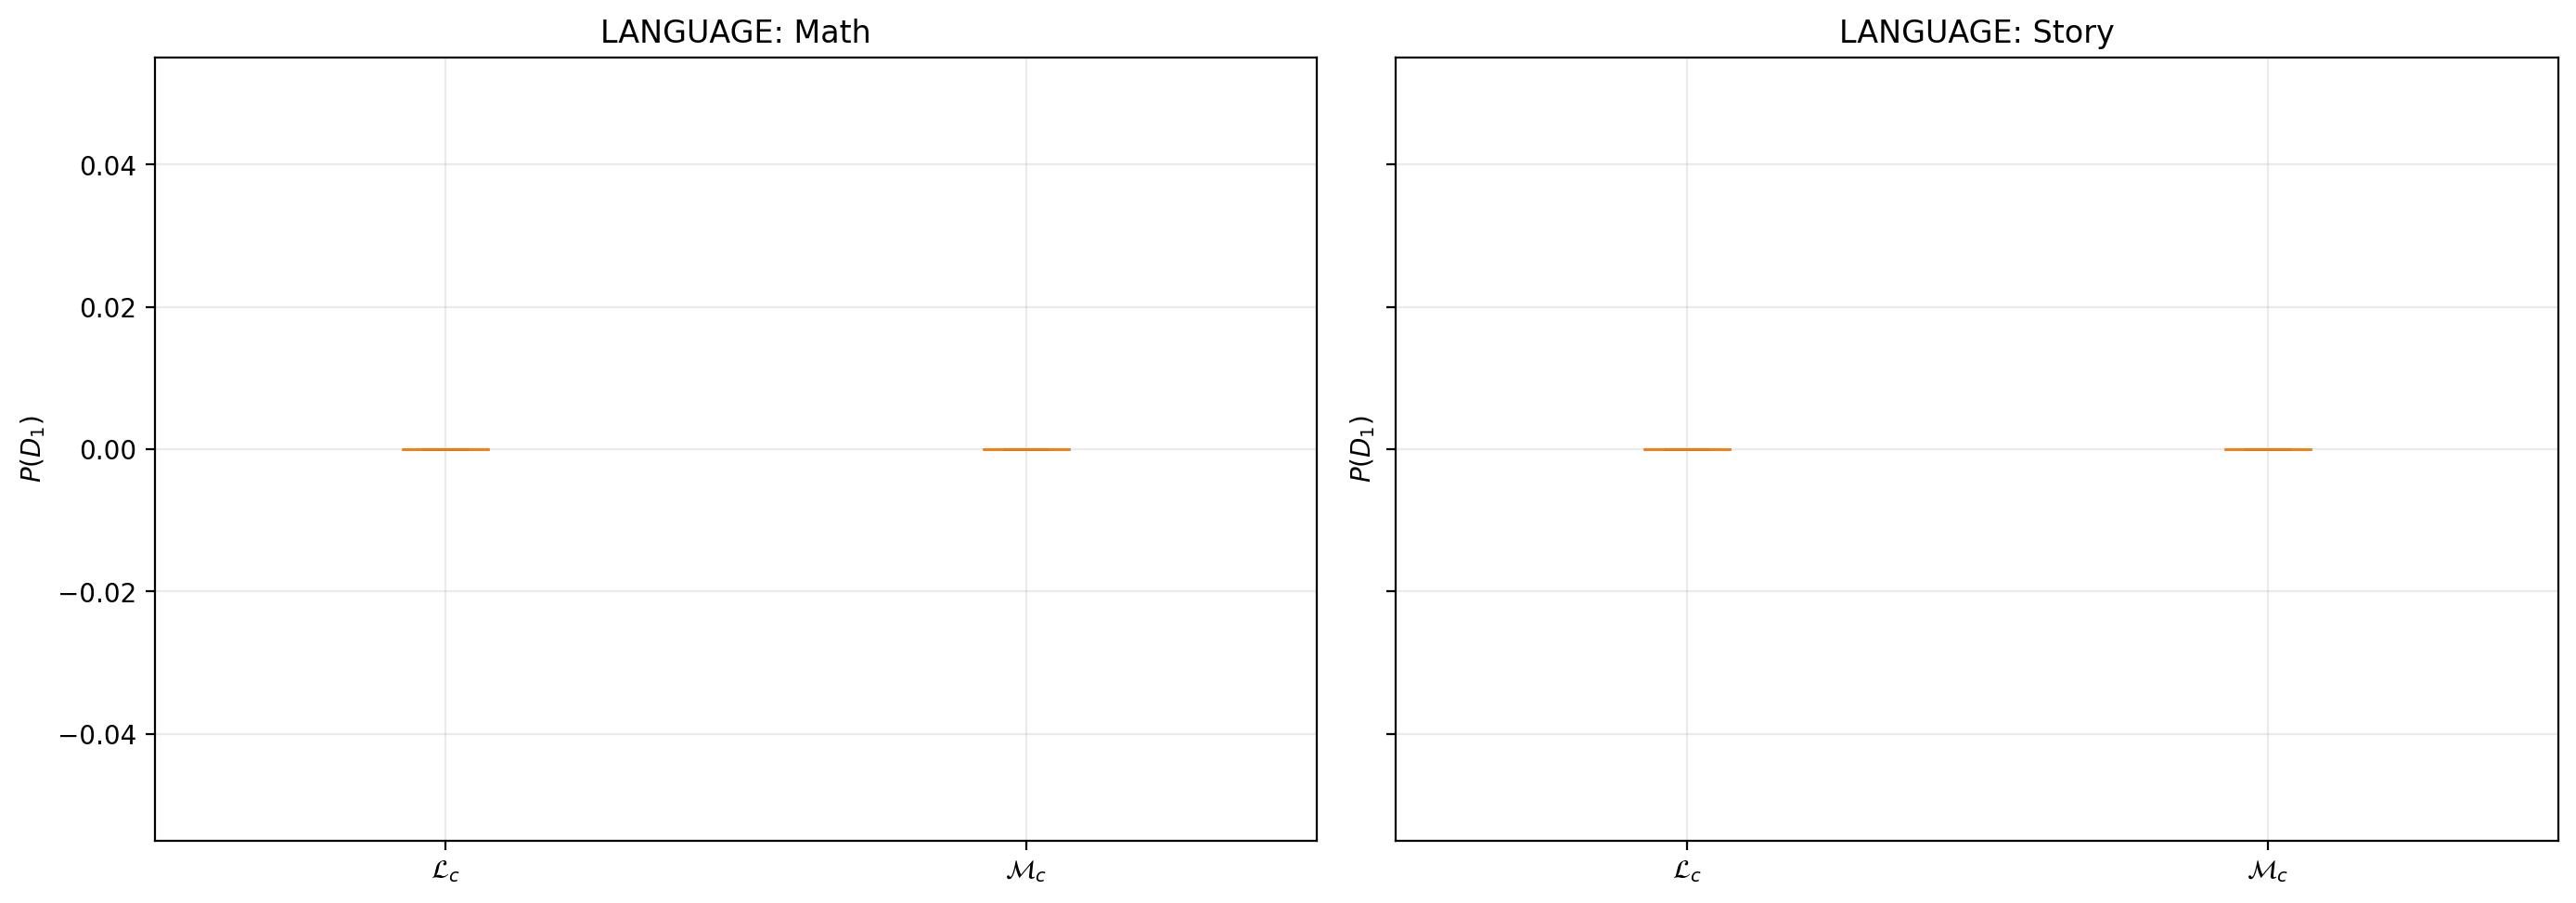

language_null_comparison.png


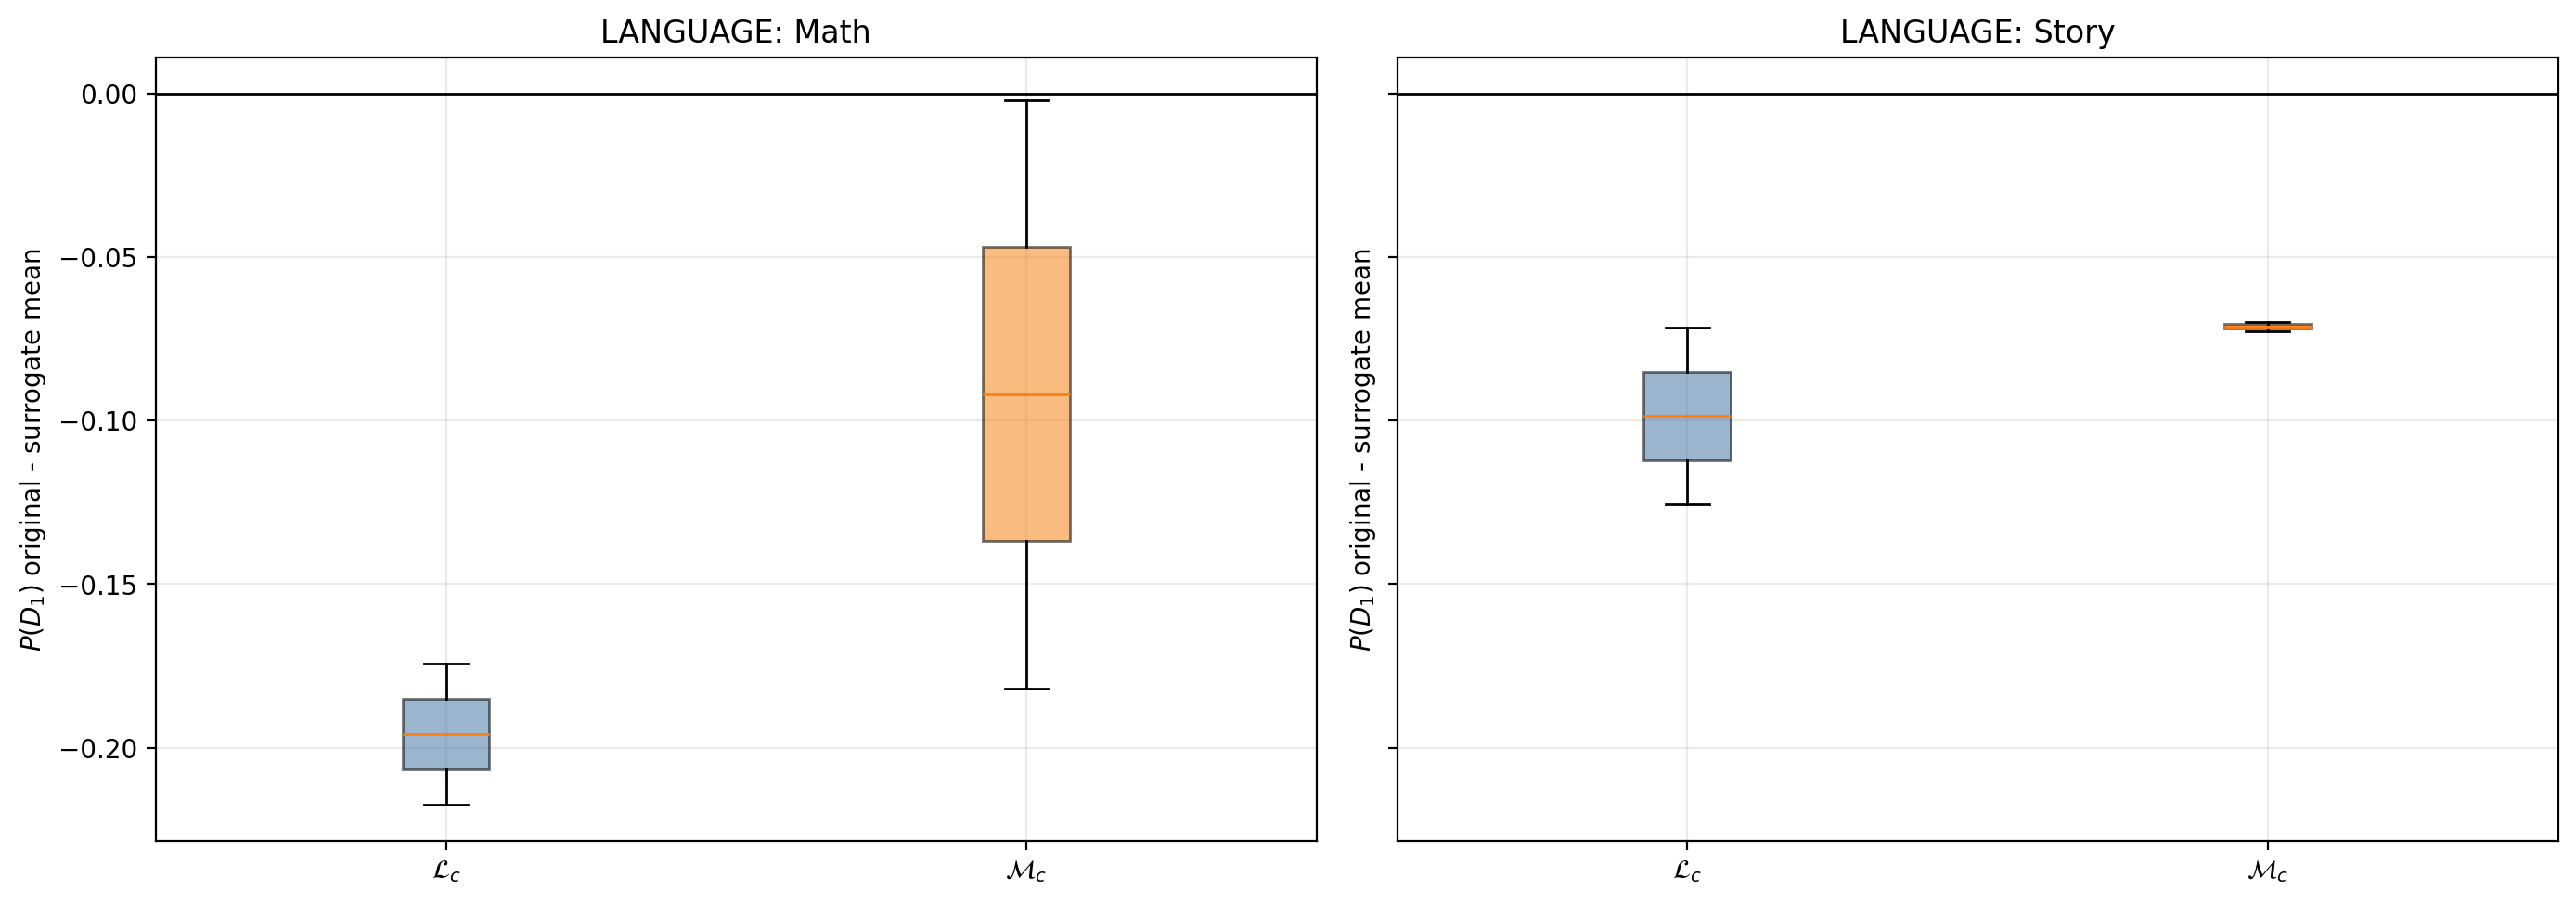

In [22]:
for path in actual_figure_paths + null_figure_paths:
    print(path.name)
    display(Image(filename=str(path)))

## 10. Direction of the Effects

These checks summarize the direction of the observed effects. They are included for auditability and should not be read as formal significance tests.

In [23]:
actual_pivot = actual_aggregate.pivot_table(
    index=["experiment", "state"],
    columns="source",
    values="H1_total_persistence_mean",
)
actual_pivot["low_minus_top"] = actual_pivot["low"] - actual_pivot["top"]
actual_pivot["low_gt_top"] = actual_pivot["low_minus_top"] > 0

null_pivot = null_aggregate.pivot_table(
    index=["experiment", "state"],
    columns="source",
    values="delta_H1_total_persistence_mean",
)
null_pivot["low_minus_top_delta"] = null_pivot["low"] - null_pivot["top"]

display(actual_pivot.reset_index())
display(null_pivot.reset_index())

source,experiment,state,low,top,low_minus_top,low_gt_top
0,LANGUAGE,math,0.0,0.0,0.0,False
1,LANGUAGE,story,0.0,0.0,0.0,False


source,experiment,state,low,top,low_minus_top_delta
0,LANGUAGE,math,-0.195923,-0.091951,-0.103972
1,LANGUAGE,story,-0.098592,-0.071236,-0.027356


## 11. Record Metadata of the Run

The canonical metadata file is `run_metadata.json`. It records the run parameters, input folders, subject/file counts, package versions, and empirical p-value resolution.

In [24]:
metadata = build_notebook_metadata(
    actual_df=actual_rows,
    null_df=null_rows,
)
write_metadata(metadata, OUTPUT_DIR)

display(pd.json_normalize(metadata))
#print("Saved:", OUTPUT_DIR / "run_metadata.json")
#print("Saved:", OUTPUT_DIR / "notebook_run_metadata.csv")

,input_summary,command,use_cache,empirical_p_resolution,actual_rows,null_rows,paper.title,paper.manuscript,parameters.experiments,parameters.phase_encoding,parameters.takens_dim,parameters.takens_delay,parameters.takens_stride,parameters.maxdim,parameters.null_model,parameters.n_surrogates,parameters.seed,parameters.max_subjects,parameters.tag,paths.project_dir,paths.data_root,paths.low_regions,paths.significant_regions,paths.output_root,paths.output_dir,software.python,software.executable,software.packages.numpy,software.packages.pandas,software.packages.matplotlib,software.packages.ripser
0,"[{'experiment': 'LANGUAGE', 'phase_encoding': ...",notebook,True,0.166667,8,8,Beyond Activation Maps: Higher-Order Informati...,paper_nips/neurips_2026.tex,[LANGUAGE],RL,3,2,1,1,shuffle,5,42,None,full_l_rl_m3_tau2_stride1_h1_5shuf_seed42,/Users/dopeyhex/Documents/Учёба/Лаборатории/М...,/Users/dopeyhex/Documents/Учёба/Лаборатории/М...,/Users/dopeyhex/Documents/Учёба/Лаборатории/М...,/Users/dopeyhex/Documents/Учёба/Лаборатории/М...,/Users/dopeyhex/Documents/Учёба/Лаборатории/М...,/Users/dopeyhex/Documents/Учёба/Лаборатории/М...,3.10.8,/Users/dopeyhex/conda/envs/caiman/bin/python,1.26.4,2.2.3,3.10.0,0.6.8
